In [2]:
import pandas as pd

In [3]:
import torch

In [4]:
from torch.utils.data import TensorDataset, DataLoader

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
import numpy as np

In [7]:
import torch.nn as nn

In [8]:
import sys
print("Python:", sys.executable)

# Try to find fastai using conda list
!conda list -n pytorch_cuda_12.4 | findstr fastai

Python: C:\Dev\miniconda3\envs\pytorch_cuda_12.4\python.exe
fastai                    2.8.7                    pypi_0    pypi
fastdownload              0.0.7                      py_0    fastai
fastprogress              1.0.3                      py_0    fastai


In [9]:
from fastai.tabular.all import *
from fastai.learner import Learner
from fastai.metrics import mae, rmse
from fastai.optimizer import Adam
import torch.nn.functional as F
import shap

In [10]:
import os

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")
print(f"CUDA version (from torch): {torch.version.cuda}")
print(f"CUDA_VISIBLE_DEVICES env var: {os.environ.get('CUDA_VISIBLE_DEVICES', 'Not set')}")
print(f"PyTorch version: {torch.__version__}")

CUDA available: True
Device count: 1
CUDA version (from torch): 12.4
CUDA_VISIBLE_DEVICES env var: Not set
PyTorch version: 2.6.0+cu124


### Load data

In [11]:
df = pd.read_csv("samples.csv")

In [12]:
df.describe()

,d,n_cos,h_cos,d_r,d_k_d_r,d_k_d_g,d_k_d_b,s_r,s_k_d_r,s_k_d_g,s_k_d_b,loss
count,2.184960e+06,2.184960e+06,2.184960e+06,2.184960e+06,2.184960e+06,2.184960e+06,2.184960e+06,2.184960e+06,2.184960e+06,2.184960e+06,2.184960e+06,2.184960e+06
mean,2.781151e-02,9.549960e-01,9.157479e-01,7.347918e-01,7.343852e-01,7.360945e-01,5.445787e-01,7.335808e-01,7.341229e-01,7.323472e-01,5.419332e-01,1.146027e-02
std,4.690012e-02,2.122836e-01,1.749415e-01,1.867426e-01,4.140916e-01,4.123851e-01,4.730500e-01,1.882552e-01,4.137108e-01,4.139700e-01,4.728327e-01,4.263463e-02
min,0.000000e+00,-9.364340e-01,-4.430460e-01,2.000000e-01,0.000000e+00,3.193000e-03,0.000000e+00,2.000000e-01,0.000000e+00,3.193000e-03,0.000000e+00,-7.956060e-01
25%,1.194000e-02,1.000000e+00,9.423968e-01,8.000000e-01,3.185490e-01,3.185490e-01,3.377000e-03,8.000000e-01,3.185490e-01,3.185490e-01,3.377000e-03,-2.370000e-03
50%,1.816700e-02,1.000000e+00,9.909490e-01,8.000000e-01,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e-01,1.000000e+00,1.000000e+00,1.000000e+00,-1.820000e-04
75%,2.990900e-02,1.000000e+00,9.971750e-01,8.000000e-01,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e-01,1.000000e+00,1.000000e+00,1.000000e+00,3.877000e-03
max,4.944530e-01,1.000000e+00,1.000000e+00,8.000000e-01,1.000000e+00,1.000000e+00,1.000000e+00,8.000000e-01,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


In [13]:
print (f"samples count {len(df)}")

samples count 2184960


### Process data

In [14]:
features = ["d", "n_cos", "h_cos", "d_r", "d_k_d_r", "d_k_d_g", "d_k_d_b", "s_r", "s_k_d_r", "s_k_d_g", "s_k_d_b"]
target = ["loss"]

In [15]:
X = df[features].values.astype(np.float32)
y = df[target].values.astype(np.float32)

In [16]:
print (f"X {X.shape} y {y.shape}")

X (2184960, 11) y (2184960, 1)


In [17]:
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

### Split the data into train, validation and test

In [18]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X_tensor, y_tensor, test_size=0.2, random_state=42
)

In [19]:
X_train.shape, X_temp.shape, y_train.shape, y_temp.shape

(torch.Size([1747968, 11]),
 torch.Size([436992, 11]),
 torch.Size([1747968, 1]),
 torch.Size([436992, 1]))

In [20]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)
X_val.shape, X_test.shape, y_val.shape, y_test.shape

(torch.Size([218496, 11]),
 torch.Size([218496, 11]),
 torch.Size([218496, 1]),
 torch.Size([218496, 1]))

### Data loaders

In [21]:
batch_size = 4096
train_loader = DataLoader (TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader (TensorDataset(X_val, y_val), batch_size=len(X_val), shuffle=True)
test_loaded = DataLoader (TensorDataset(X_test, y_test), batch_size=len(X_test), shuffle=True)

In [22]:
dls = DataLoaders(train_loader, val_loader)  # your existing DataLoaders

### Model

In [23]:
class Model(nn.Module):
    def __init__(self, input_dim = 11, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        return self.net(x)

### Training

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Model(input_dim=11, hidden_dim=64).to(device)
loss_fn = nn.MSELoss()   # or nn.L1Loss() for MAE

print (f"using device {device}")

using device cuda


In [25]:
def custom_rmse(pred, target):
    return torch.sqrt(F.mse_loss(pred, target))

learn = Learner(
    dls=dls,
    model=model,
    opt_func=Adam,
    loss_func=nn.MSELoss(),
    metrics=[mae, custom_rmse]
)

SuggestedLRs(valley=0.00010964782268274575)

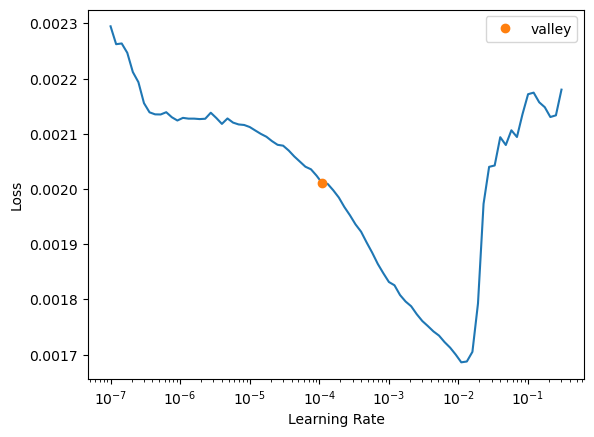

In [26]:
learn.lr_find()

In [27]:
learn.fit_one_cycle(7, lr_max=0.00047863)

epoch,train_loss,valid_loss,mae,custom_rmse,time
0,0.001158,0.001152,0.015356,0.033941,00:25
1,0.001147,0.001152,0.016201,0.033944,00:26
2,0.001138,0.001138,0.015059,0.033734,00:24
3,0.001149,0.001138,0.015260,0.033731,00:27
4,0.001140,0.001135,0.015007,0.033691,00:26
5,0.001140,0.001135,0.014956,0.033689,00:26
6,0.001140,0.001135,0.014984,0.033684,00:26


### Let's test the test data

In [28]:
learn.model.eval()

Model(
  (net): Sequential(
    (0): Linear(in_features=11, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [29]:
X_test_device = X_test.to(device)
y_test_device = y_test.to(device)

In [30]:
with torch.no_grad():
    predictions = learn.model(X_test_device)
    test_loss = nn.MSELoss()(predictions, y_test_device)
    test_mae = torch.abs(predictions - y_test_device).mean()
    test_rmse = torch.sqrt(((predictions - y_test_device) ** 2).mean())

In [31]:
print(f"Test Loss (MSE): {test_loss:.6f}")
print(f"Test MAE: {test_mae:.6f}")
print(f"Test RMSE: {test_rmse:.6f}")

Test Loss (MSE): 0.001133
Test MAE: 0.015037
Test RMSE: 0.033665


In [66]:
background_data = X_tensor[:10000]
background = background_data.to(device)

In [67]:
explainer = shap.DeepExplainer(model, background)

In [68]:
test_samples = X_test[:1000].to(device)

In [70]:
shap_values = explainer.shap_values(test_samples)

In [71]:
print(f"SHAP values shape: {np.array(shap_values).shape}")
print(f"Test samples shape: {test_samples.shape}")
print(f"Type of shap_values: {type(shap_values)}")

shap_values = np.squeeze(shap_values, axis=-1)
print(f"New shape: {shap_values.shape}")

SHAP values shape: (1000, 11, 1)
Test samples shape: torch.Size([1000, 11])
Type of shap_values: <class 'numpy.ndarray'>
New shape: (1000, 11)


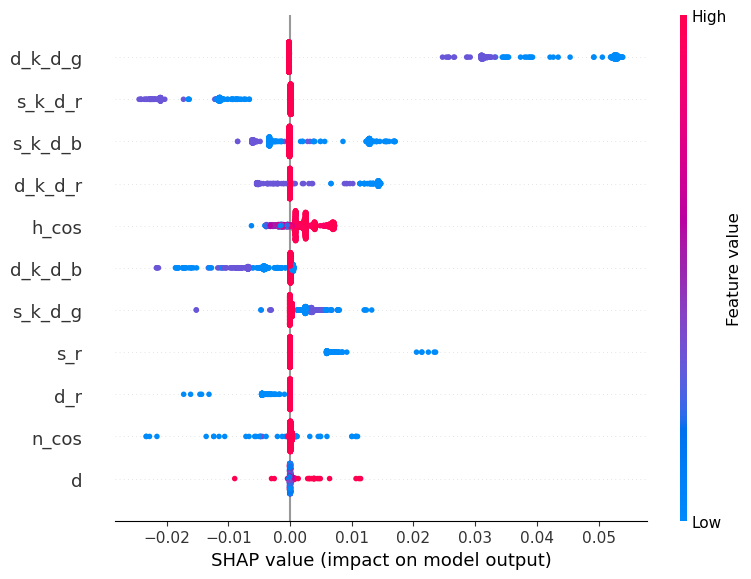

In [72]:
shap.summary_plot(shap_values, test_samples.cpu().numpy(), 
                  feature_names=features)

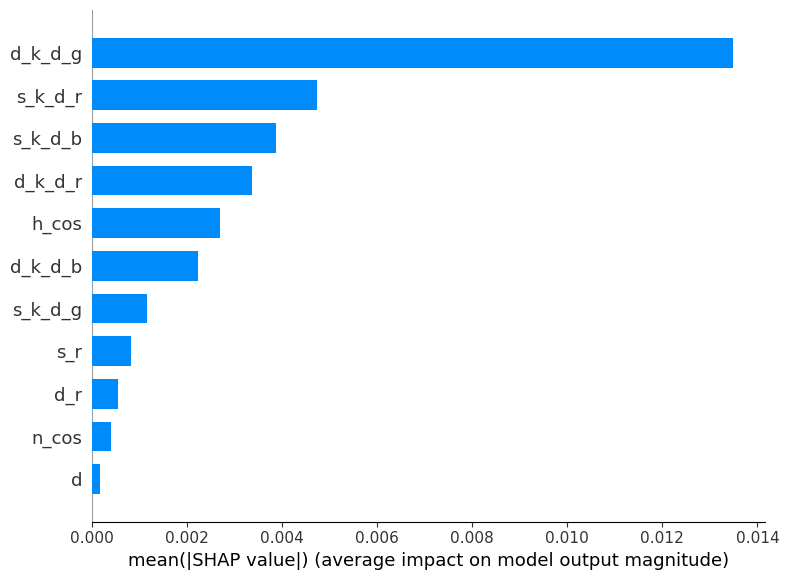

In [73]:
shap.summary_plot(shap_values, test_samples.cpu().numpy(), 
                  feature_names=features, plot_type="bar")

### Save the model

In [67]:
learn.model.cpu()  # Move to CPU

# Then export
torch.jit.script(learn.model).save("join_predictor.pt")

In [68]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Total parameters: 4,993


In [69]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

l1w = 11 * 64
l1b = 64
l1 = l1w + l1b
l2w = 64 * 64
l2b = 64
l2 = l2w + l2b
l3w = 64 * 1
l3b = 1
l3 = l3w + l3b
print (f"Manually computed: {l1 + l2 + l3:,}")
print (f"layer 1 {l1:,} weights {l1w:,} size {l1w*4:,} bias {l1b:,} size {l1b*4:,} ");
print (f"layer 2 {l2:,} weights {l2w:,} size {l2w*4:,} bias {l2b:,} size {l2b*4:,} ");
print (f"layer 3 {l3:,} weights {l3w:,} size {l3w*4:,} bias {l3b:,} size {l3b*4:,} ");


Total parameters: 4,993
Manually computed: 4,993
layer 1 768 weights 704 size 2,816 bias 64 size 256 
layer 2 4,160 weights 4,096 size 16,384 bias 64 size 256 
layer 3 65 weights 64 size 256 bias 1 size 4 
